# Source-Space RSA — Brain Visualisation

Loads per-subject source RSA maps (morphed to fsaverage) and group noise ceiling
from the HPC share and creates publication-quality brain plots.

**Workflow:**
1. Load per-subject morphed `.stc` files and compute group average
2. Optionally load noise ceiling STC and compute RSA / noise ceiling ratio
3. Plot brain maps (lateral / medial, pial / inflated)
4. Save standalone colorbar
5. Subject consistency check

Run `compute_source_rsa.py` on the HPC first to produce the `.stc` files.

In [7]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import mne

sns.set_context('poster')
plt.rcParams['svg.fonttype'] = 'none'

print('Libraries loaded.')

Libraries loaded.


## Configuration

In [62]:
# ── Subject / model parameters ────────────────────────────────────────────────
subjects   = [1, 2, 3, 4, 5]
model_name = 'resnet50_ecoset_crop'
layer      = 'layer3'                                    # single layer for RSA maps
layers     = ['layer1', 'layer2', 'layer3', 'layer4', 'avgpool']   # all layers for WTA map

# ── SSH-mount paths ───────────────────────────────────────────────────────────
avs_dir   = '/Users/atlas/avs'
share_dir = '/Users/atlas/share_psulewski/psulewski'

subjects_dir = f'{avs_dir}/rawdir/'   # FreeSurfer subjects dir
rsa_dir      = f'{share_dir}/pyavs/source_rsa/'
morph_to     = 'fsaverage'

# ── Output ────────────────────────────────────────────────────────────────────
# output_dir = os.path.join(share_dir, 'pyavs', 'source_rsa_figures',
#                           f'model-{model_name}_layer-{layer}')
output_dir = os.path.join('/Users/atlas/Documents/Documents_atlas/PhD/code/pyavs_conversion/pyavs/scripts/rsa_analysis', 'source_rsa_figures',
                          f'model-{model_name}_layer-{layer}')
os.makedirs(output_dir, exist_ok=True)

# ── Visualisation parameters ──────────────────────────────────────────────────
surfaces = ['pial']
views    = ['lateral', 'medial']

colormap = 'magma'

# Color limits for Pearson r (set vmax=None for auto from 99th percentile)
vmin = 0.0
vmid = None   # None → auto midpoint
vmax = 0.45 # None → auto 99th percentile of group average

print(f'Model: {model_name}  Layer: {layer}')
print(f'Layers (WTA): {layers}')
print(f'Subjects: {subjects}')
print(f'RSA dir: {rsa_dir}')
print(f'Output:  {output_dir}')

Model: resnet50_ecoset_crop  Layer: layer3
Layers (WTA): ['layer1', 'layer2', 'layer3', 'layer4', 'avgpool']
Subjects: [1, 2, 3, 4, 5]
RSA dir: /Users/atlas/share_psulewski/psulewski/pyavs/source_rsa/
Output:  /Users/atlas/Documents/Documents_atlas/PhD/code/pyavs_conversion/pyavs/scripts/rsa_analysis/source_rsa_figures/model-resnet50_ecoset_crop_layer-layer3


## Function Definitions

In [9]:
def load_subject_rsa_stc(subject_id, rsa_dir, model_name, layer):
    """Load a morphed source RSA map for one subject."""
    fname = os.path.join(
        rsa_dir,
        f'sub-{subject_id:02d}',
        f'sub-{subject_id:02d}_model-{model_name}_layer-{layer}_source_rsa',
    )
    if not (os.path.exists(fname + '-lh.stc') and
            os.path.exists(fname + '-rh.stc')):
        print(f'  WARNING: STC not found for sub-{subject_id:02d} — skipping.')
        return None
    stc = mne.read_source_estimate(fname)
    print(f'  sub-{subject_id:02d}: {stc.data.shape[0]} vertices, '
          f'r range [{stc.data.min():.3f}, {stc.data.max():.3f}]')
    return stc


def load_noise_ceiling_stc(rsa_dir, model_name, layer):
    """Load group noise ceiling upper-bound STC."""
    fname = os.path.join(
        rsa_dir,
        f'group_model-{model_name}_layer-{layer}_noise_ceiling_upper',
    )
    if not (os.path.exists(fname + '-lh.stc') and
            os.path.exists(fname + '-rh.stc')):
        print('WARNING: noise ceiling STC not found.')
        return None
    stc = mne.read_source_estimate(fname)
    print(f'Noise ceiling: {stc.data.shape[0]} vertices, '
          f'range [{stc.data.min():.3f}, {stc.data.max():.3f}]')
    return stc


def compute_group_average(stcs):
    """Average source estimates across subjects."""
    data_stack = np.stack([s.data for s in stcs], axis=0)   # (n_subs, n_verts, 1)
    avg_data   = np.mean(data_stack, axis=0)
    avg_stc    = stcs[0].copy()
    avg_stc.data = avg_data
    return avg_stc


def auto_clim(stc, vmin=0.0, quantile=0.99):
    """Derive color limits from the STC data."""
    vals = stc.data.ravel()
    vmax = float(np.quantile(vals, quantile))
    vmid = (vmin + vmax) / 2
    return vmin, vmid, vmax


def plot_brain(
    stc, surface, view,
    subjects_dir, morph_to, colormap,
    vmin, vmid, vmax,
    save_path=None,
):
    """
    Render a brain plot for a single-timepoint STC.

    Parameters
    ----------
    stc : mne.SourceEstimate
    surface : str
        'pial' or 'inflated'
    view : str
        'lateral' or 'medial'
    subjects_dir, morph_to, colormap : str
    vmin, vmid, vmax : float
    save_path : str or None
        Path without extension — saves .png if provided.

    Returns
    -------
    mne.viz.Brain
    """
    brain = stc.plot(
        subject=morph_to,
        subjects_dir=subjects_dir,
        initial_time=stc.tmin,
        hemi='split',
        time_viewer=False,
        colorbar=False,
        colormap=colormap,
        clim=dict(kind='value', lims=[vmin, vmid, vmax]),
        smoothing_steps=3,
        transparent=False,
        surface=surface,
        background='white',
        views=view,
        size=(900, 450),
    )

    if save_path:
        brain.save_image(save_path + '.png')
        print(f'    Saved: {os.path.basename(save_path)}.png')

    return brain


def create_colorbar(vmin, vmid, vmax, colormap, output_dir,
                    label='spearman rho', fname='colorbar'):
    """Save a standalone horizontal colorbar figure."""
    plt.figure(figsize=(5.5, 3.4))
    ax = plt.gca()

    mne.viz.plot_brain_colorbar(
        ax,
        clim=dict(kind='value', lims=[vmin, vmid, vmax]),
        colormap=colormap,
        transparent=False,
        orientation='horizontal',
    )

    ticks = np.linspace(vmin, vmax, 3)
    ax.set_xticks(ticks)
    ax.set_xticklabels([f'{t:.2f}' for t in ticks])
    ax.set_xlabel(label)
    ax.tick_params(tick1On=False)

    sns.despine()
    plt.tight_layout()

    for ext in ('png', 'pdf'):
        fpath = os.path.join(output_dir, f'{fname}.{ext}')
        plt.savefig(fpath, dpi=300, bbox_inches='tight',
                    facecolor='white', edgecolor='none')
    plt.show()
    print(f'Colorbar saved to {output_dir}')


print('Functions defined.')

Functions defined.


In [10]:
def load_subject_all_layers_stcs(subject_id, rsa_dir, model_name, layers):
    """Load RSA STCs for all layers for one subject.

    Returns
    -------
    dict mapping layer name -> mne.SourceEstimate, or None for missing layers.
    """
    result = {}
    for lyr in layers:
        stc = load_subject_rsa_stc(subject_id, rsa_dir, model_name, lyr)
        result[lyr] = stc  # None if missing
    return result


def compute_wta_stc(all_layers_stcs, layers):
    """Compute winner-take-all layer map via per-subject WTA + majority vote.

    For each subject, the winning layer at each vertex is determined by argmax
    across layers. The group WTA map is then the majority vote across subjects
    (i.e. the layer that won the most subjects at each vertex).

    Parameters
    ----------
    all_layers_stcs : dict, layer -> list of per-subject mne.SourceEstimate
    layers : list of str

    Returns
    -------
    wta_stc : mne.SourceEstimate
        Integer-valued STC (0-based layer index) in fsaverage space.
    winner_counts : dict
        Number of vertices won by each layer in the group map.
    """
    n_subjects = len(all_layers_stcs[layers[0]])
    n_vertices = all_layers_stcs[layers[0]][0].data.shape[0]

    # win_counts[layer_i, vertex] = number of subjects where layer_i won
    win_counts = np.zeros((len(layers), n_vertices), dtype=int)

    for s in range(n_subjects):
        data_stack = np.stack(
            [all_layers_stcs[lyr][s].data[:, 0] for lyr in layers], axis=0
        )  # (n_layers, n_vertices)
        subject_winner = np.argmax(data_stack, axis=0)  # (n_vertices,)
        for i in range(len(layers)):
            win_counts[i] += (subject_winner == i)

    # Majority vote across subjects
    group_winner = np.argmax(win_counts, axis=0).astype(float)

    wta_stc = all_layers_stcs[layers[0]][0].copy()
    wta_stc.data = group_winner[:, np.newaxis]

    winner_counts = {
        lyr: int((group_winner == i).sum()) for i, lyr in enumerate(layers)
    }
    return wta_stc, winner_counts, win_counts


print('Multi-layer functions defined.')

Multi-layer functions defined.


## Load Per-Subject RSA STCs

In [11]:
print(f'Loading RSA STCs from: {rsa_dir}\n')

stcs = []
loaded_subjects = []

for sub in subjects:
    stc = load_subject_rsa_stc(sub, rsa_dir, model_name, layer)
    if stc is not None:
        stcs.append(stc)
        loaded_subjects.append(sub)

print(f'\nLoaded {len(stcs)}/{len(subjects)} subjects: {loaded_subjects}')

Loading RSA STCs from: /Users/atlas/share_psulewski/psulewski/pyavs/source_rsa/

  sub-01: 20484 vertices, r range [-0.020, 0.553]
  sub-02: 20484 vertices, r range [-0.013, 0.583]
  sub-03: 20484 vertices, r range [-0.011, 0.523]
  sub-04: 20484 vertices, r range [0.002, 0.444]
  sub-05: 20484 vertices, r range [-0.009, 0.397]

Loaded 5/5 subjects: [1, 2, 3, 4, 5]


## Group Average & Color Limits

In [63]:
if not stcs:
    raise RuntimeError('No STCs loaded — check rsa_dir and run compute_source_rsa.py first.')

avg_stc = compute_group_average(stcs)

print(f'Group average shape: {avg_stc.data.shape}')
print(f'Value range: {avg_stc.data.min():.4f} – {avg_stc.data.max():.4f}')

if vmax is None:
    _vmin, _vmid, _vmax = auto_clim(avg_stc, vmin=vmin)
    print(f'\nAuto color limits: vmin={_vmin:.3f}, vmid={_vmid:.3f}, vmax={_vmax:.3f}')
else:
    _vmin = vmin
    _vmid = vmid if vmid is not None else (vmin + vmax) / 2
    _vmax = vmax
    print(f'\nManual color limits: vmin={_vmin:.3f}, vmid={_vmid:.3f}, vmax={_vmax:.3f}')

Group average shape: (20484, 1)
Value range: 0.0472 – 0.4345

Manual color limits: vmin=0.000, vmid=0.225, vmax=0.450


## Brain Plots — Group Average RSA

One image per `(surface, view)` combination.

In [64]:
print('Generating brain plots (group average RSA)...\n')

for surface in surfaces:
    for view in views:
        fname = f'group_rsa_{surface}_{view}'
        save_path = os.path.join(output_dir, fname)
        try:
            brain = plot_brain(
                stc=avg_stc,
                surface=surface, view=view,
                subjects_dir=subjects_dir, morph_to=morph_to,
                colormap=colormap,
                vmin=_vmin, vmid=_vmid, vmax=_vmax,
                save_path=save_path,
            )
            #brain.close()
        except Exception as e:
            print(f'  ERROR ({surface}, {view}): {e}')

print('\nBrain plots done.')

Generating brain plots (group average RSA)...

    Saved: group_rsa_pial_lateral.png
    Saved: group_rsa_pial_medial.png

Brain plots done.


## Standalone Colorbar

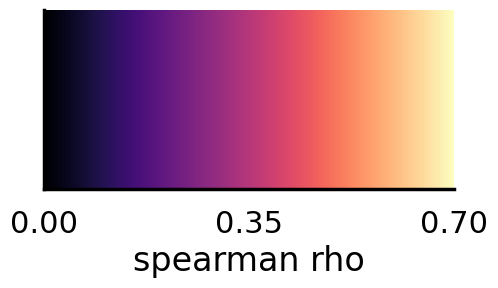

Colorbar saved to /Users/atlas/Documents/Documents_atlas/PhD/code/pyavs_conversion/pyavs/scripts/rsa_analysis/source_rsa_figures/model-resnet50_ecoset_crop_layer-layer3


In [14]:
create_colorbar(
    vmin=_vmin, vmid=_vmid, vmax=_vmax,
    colormap=colormap,
    output_dir=output_dir,
    label='spearman rho',
)

## Noise Ceiling

Load the group noise ceiling STC and plot it alongside the RSA map.
Also compute the normalised RSA (RSA / noise ceiling) to show explained variance.

In [15]:
nc_stc = load_noise_ceiling_stc(rsa_dir, model_name, layer)

Noise ceiling: 20484 vertices, range [0.449, 0.722]



Generating noise ceiling and normalised RSA plots...

    Saved: group_noise_ceiling_pial_lateral.png
    Saved: group_noise_ceiling_pial_medial.png


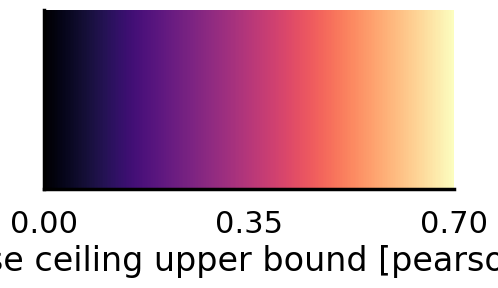

Colorbar saved to /Users/atlas/Documents/Documents_atlas/PhD/code/pyavs_conversion/pyavs/scripts/rsa_analysis/source_rsa_figures/model-resnet50_ecoset_crop_layer-layer3

Normalised RSA color limits: 0.000 – 0.623
    Saved: group_rsa_normalised_pial_lateral.png
    Saved: group_rsa_normalised_pial_medial.png


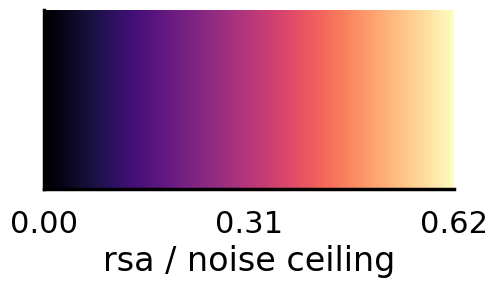

Colorbar saved to /Users/atlas/Documents/Documents_atlas/PhD/code/pyavs_conversion/pyavs/scripts/rsa_analysis/source_rsa_figures/model-resnet50_ecoset_crop_layer-layer3


In [16]:
if nc_stc is not None:
    print('\nGenerating noise ceiling and normalised RSA plots...\n'
 )
    # ── Brain plot: noise ceiling ────────────────────────────────────────────
    nc_vmin, nc_vmid, nc_vmax = _vmin, _vmid, _vmax
   
    for surface in surfaces:
        for view in views:
            fname = f'group_noise_ceiling_{surface}_{view}'
            save_path = os.path.join(output_dir, fname)
            
            brain = plot_brain(
                stc=nc_stc,
                surface=surface, view=view,
                subjects_dir=subjects_dir, morph_to=morph_to,
                colormap=colormap,
                vmin=nc_vmin, vmid=nc_vmid, vmax=nc_vmax,
                save_path=save_path,
            )
            brain.close()
            

    create_colorbar(
        vmin=nc_vmin, vmid=nc_vmid, vmax=nc_vmax,
        colormap=colormap,
        output_dir=output_dir,
        label='noise ceiling upper bound [pearson r]',
        fname='colorbar_noise_ceiling',
    )

    # ── Normalised RSA (RSA / noise ceiling) ────────────────────────────────
    # Mask vertices where noise ceiling ≈ 0 to avoid division artefacts
    nc_data = nc_stc.data.ravel()
    rsa_data = avg_stc.data.ravel()

    norm_data = np.where(
        nc_data > 0.01,
        rsa_data / nc_data,
        0.0,
    )
    norm_stc = avg_stc.copy()
    norm_stc.data = norm_data[:, np.newaxis]

    norm_vmin, norm_vmid, norm_vmax = auto_clim(norm_stc, vmin=0.0)
    print(f'\nNormalised RSA color limits: {norm_vmin:.3f} – {norm_vmax:.3f}')

    for surface in surfaces:
        for view in views:
            fname = f'group_rsa_normalised_{surface}_{view}'
            save_path = os.path.join(output_dir, fname)
            try:
                brain = plot_brain(
                    stc=norm_stc,
                    surface=surface, view=view,
                    subjects_dir=subjects_dir, morph_to=morph_to,
                    colormap=colormap,
                    vmin=norm_vmin, vmid=norm_vmid, vmax=norm_vmax,
                    save_path=save_path,
                )
                brain.close()
            except Exception as e:
                print(f'  ERROR ({surface}, {view}): {e}')

    create_colorbar(
        vmin=norm_vmin, vmid=norm_vmid, vmax=norm_vmax,
        colormap=colormap,
        output_dir=output_dir,
        label='rsa / noise ceiling',
        fname='colorbar_normalised',
    )
else:
    print('Skipping noise ceiling plots (STC not found).')

## Subject Consistency Check

Distribution of per-subject RSA values across vertices, overlaid with the group average.
Useful for spotting outlier subjects before committing to the full brain render.

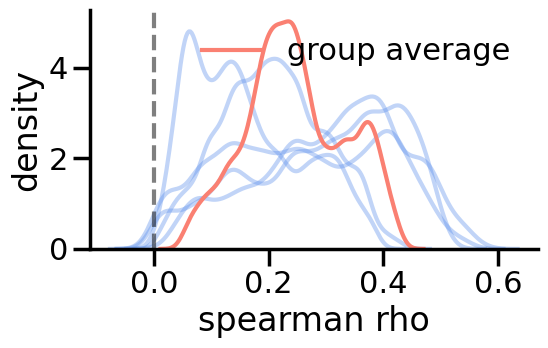

Saved: /Users/atlas/Documents/Documents_atlas/PhD/code/pyavs_conversion/pyavs/scripts/rsa_analysis/source_rsa_figures/model-resnet50_ecoset_crop_layer-layer3/subject_rsa_distributions.png


In [17]:
plt.figure(figsize=(6, 4))

for stc_s, sub in zip(stcs, loaded_subjects):
    vals = stc_s.data.ravel()
    sns.kdeplot(vals, color='cornflowerblue', alpha=0.4)

# Group average on top
sns.kdeplot(avg_stc.data.ravel(), color='salmon', label='group average')

plt.axvline(x=0, color='black', linestyle='--', alpha=0.5)
plt.xlabel('spearman rho')
plt.ylabel('density')
plt.legend(frameon=False)
sns.despine()
plt.tight_layout()

fpath = os.path.join(output_dir, 'subject_rsa_distributions')
for ext in ('png', 'pdf'):
    plt.savefig(f'{fpath}.{ext}', dpi=300, bbox_inches='tight',
                facecolor='white', edgecolor='none')
plt.show()
print(f'Saved: {fpath}.png')

## Subject × Vertex Correlation (split-half reliability)

For each pair of subjects, compute the vertex-wise Pearson correlation of their RSA maps.
A high average inter-subject correlation indicates a reliable group pattern.

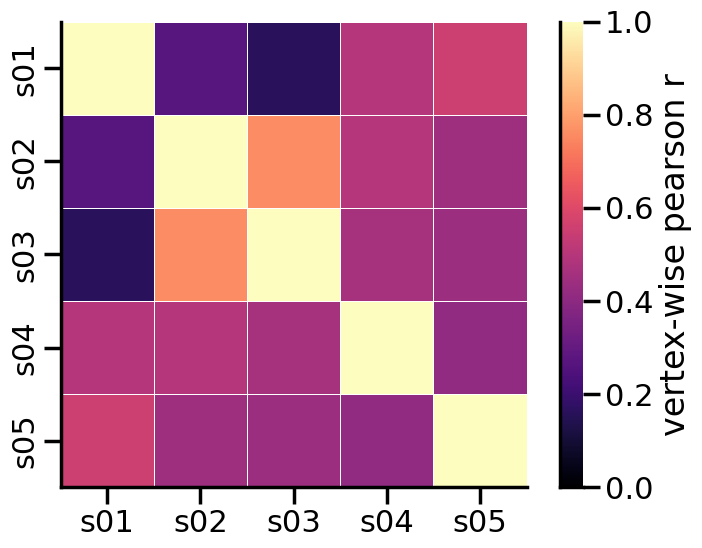

Mean inter-subject vertex-wise r = 0.449
Saved: /Users/atlas/Documents/Documents_atlas/PhD/code/pyavs_conversion/pyavs/scripts/rsa_analysis/source_rsa_figures/model-resnet50_ecoset_crop_layer-layer3/intersubject_rsa_correlation.png


In [18]:
from itertools import combinations

n = len(stcs)
corr_matrix = np.full((n, n), np.nan)

for i, j in combinations(range(n), 2):
    a = stcs[i].data.ravel()
    b = stcs[j].data.ravel()
    r = np.corrcoef(a, b)[0, 1]
    corr_matrix[i, j] = r
    corr_matrix[j, i] = r

np.fill_diagonal(corr_matrix, 1.0)

# ── Plot ─────────────────────────────────────────────────────────────────────
plt.figure(figsize=(8, 6))
sns.heatmap(
    corr_matrix,
    xticklabels=[f's{s:02d}' for s in loaded_subjects],
    yticklabels=[f's{s:02d}' for s in loaded_subjects],
    vmin=0.0, vmax=1.0,
    cmap='magma',
    square=True,
    cbar_kws={'label': 'vertex-wise pearson r'},
    linewidths=0.5,
)
sns.despine()
plt.tight_layout()

fpath = os.path.join(output_dir, 'intersubject_rsa_correlation')
for ext in ('png', 'pdf'):
    plt.savefig(f'{fpath}.{ext}', dpi=300, bbox_inches='tight',
                facecolor='white', edgecolor='none')
plt.show()

off_diag = corr_matrix[np.triu_indices(n, k=1)]
print(f'Mean inter-subject vertex-wise r = {np.nanmean(off_diag):.3f}')
print(f'Saved: {fpath}.png')

In [19]:
# ── ROI definitions ───────────────────────────────────────────────────────────
compound_rois = {
    'early':   ['early'],                                        # Early visual cortex
    'parietal': ['midparietal', 'parietal'],
    'lateral': ['midlateral', 'lateral'],                        # Lateral visual cortex
    'ventral': ['midventral', 'ventral'],                        # Ventral visual cortex
    'HC':      ['H'],                                            # Hippocampus
    'FEF':     ['FEF'],                                          # Frontal eye fields
    'dlPFC':   ['8C', '8Av', 'i6-8', 's6-8', 'SFL', '8BL', '9p', '9a', '8Ad',
                'p9-46v', 'a9-46v', '46', '9-46d'],             # Dorsolateral prefrontal cortex
    'OFC':     ['47s', '47m', 'a47r', '11l', '13l', 'a10p', 'p10p', '10pp',
                '10d', 'OFC', 'pOFC'],                          # Orbitofrontal cortex
    'infFC':   ['45', 'IFJp', 'IFJa', 'IFSp', 'IFSa', '47l', 'p47r'],  # Inferior frontal cortex
    'mPFC':    ['33pr', 'p24pr', 'a24pr', 'p24', 'a24', 'p32pr', 'a32pr',
                'd32', 'p32', 's32', '8BM', '9m', '10v', '10r', '25'],  # Medial prefrontal cortex
}
fsaverage_label_dir = f'{subjects_dir}/fsaverage/label'

# Load labels (fsaverage space; shared across subjects)
roi_labels = {}
for roi, sub_rois in compound_rois.items():
    roi_labels[roi] = {}
    for hemi, prefix in [('lh', 'L'), ('rh', 'R')]:
        roi_labels[roi][hemi] = []
        for sub_roi in sub_rois:
            fname = os.path.join(fsaverage_label_dir, f'{hemi}.{prefix}_{sub_roi}_ROI.label')
            roi_labels[roi][hemi].append(mne.read_label(fname))

# Extract per-subject mean RSA per ROI and hemisphere
rows = []
for subj_idx, stc in enumerate(stcs):
    for roi, hemi_labels in roi_labels.items():
        for hemi, labels in hemi_labels.items():
            vals = []
            for label in labels:
                try:
                    stc_in = stc.in_label(label)
                    vals.append(stc_in.data.mean())
                except Exception:
                    pass  # label has no vertices in this stc
            if vals:
                rows.append({
                    'subject': subj_idx + 1,
                    'roi': roi,
                    'hemi': hemi,
                    'rsa': float(np.mean(vals)),
                })

roi_df = pd.DataFrame(rows)
print(roi_df)

# Extract mean NC per ROI and hemisphere from group noise ceiling STC
nc_rows = []
if nc_stc is not None:
    for roi, hemi_labels in roi_labels.items():
        for hemi, labels in hemi_labels.items():
            vals = []
            for label in labels:
                try:
                    stc_in = nc_stc.in_label(label)
                    vals.append(stc_in.data.mean())
                except Exception:
                    pass
            if vals:
                nc_rows.append({'roi': roi, 'hemi': hemi, 'nc': float(np.mean(vals))})

nc_df = pd.DataFrame(nc_rows)
print(nc_df)

    subject       roi hemi       rsa
0         1     early   lh  0.449229
1         1     early   rh  0.402004
2         1  parietal   lh  0.407780
3         1  parietal   rh  0.401435
4         1   lateral   lh  0.439493
..      ...       ...  ...       ...
95        5       OFC   rh  0.182955
96        5     infFC   lh  0.112160
97        5     infFC   rh  0.134651
98        5      mPFC   lh  0.113949
99        5      mPFC   rh  0.123797

[100 rows x 4 columns]
         roi hemi        nc
0      early   lh  0.673889
1      early   rh  0.647222
2   parietal   lh  0.670982
3   parietal   rh  0.636634
4    lateral   lh  0.662115
5    lateral   rh  0.631665
6    ventral   lh  0.636586
7    ventral   rh  0.626134
8         HC   lh  0.532412
9         HC   rh  0.575358
10       FEF   lh  0.482445
11       FEF   rh  0.511153
12     dlPFC   lh  0.495387
13     dlPFC   rh  0.501946
14       OFC   lh  0.518815
15       OFC   rh  0.545394
16     infFC   lh  0.537071
17     infFC   rh  0.566569


In [20]:

# ── Source data export ────────────────────────────────────────────────────────
# Count unique vertices per ROI × hemisphere (union across sub-labels)
n_sources_rows = []
for roi, hemi_labels in roi_labels.items():
    for hemi, labels in hemi_labels.items():
        all_verts = set()
        for lbl in labels:
            all_verts.update(lbl.vertices.tolist())
        n_sources_rows.append({'roi': roi, 'hemi': hemi, 'n_sources': len(all_verts)})

n_sources_df = pd.DataFrame(n_sources_rows)

# Merge n_sources into roi_df and nc_df
roi_df_out = roi_df.merge(n_sources_df, on=['roi', 'hemi'], how='left')

source_data_dir = os.path.join(output_dir, 'source_data')
os.makedirs(source_data_dir, exist_ok=True)

roi_df_out.to_csv(os.path.join(source_data_dir, 'source_rsa_roi_source_data.csv'), index=False)
print(f'Saved per-subject ROI source data → source_data/source_rsa_roi_source_data.csv')
print(roi_df_out.to_string(index=False))


Saved per-subject ROI source data → source_data/source_rsa_roi_source_data.csv
 subject      roi hemi      rsa  n_sources
       1    early   lh 0.449229       5756
       1    early   rh 0.402004       5633
       1 parietal   lh 0.407780       6248
       1 parietal   rh 0.401435       6002
       1  lateral   lh 0.439493      11346
       1  lateral   rh 0.346399      11730
       1  ventral   lh 0.383930      10540
       1  ventral   rh 0.328585      10441
       1       HC   lh 0.166677       1265
       1       HC   rh 0.118555        897
       1      FEF   lh 0.301144        832
       1      FEF   rh 0.296941        850
       1    dlPFC   lh 0.179715      11087
       1    dlPFC   rh 0.220999      11163
       1      OFC   lh 0.126814       7299
       1      OFC   rh 0.226922       7772
       1    infFC   lh 0.250593       4467
       1    infFC   rh 0.247238       3922
       1     mPFC   lh 0.160935       7874
       1     mPFC   rh 0.122593       8736
       2    early 

In [21]:

# ── Stats txt export ─────────────────────────────────────────────────────────
from scipy.stats import bootstrap as scipy_bootstrap

N_BOOTSTRAP = 10_000

def _bca_ci(values, n_bootstrap=N_BOOTSTRAP):
    """Bootstrapped 95% CI (BCa) across subjects."""
    res = scipy_bootstrap(
        (np.asarray(values),), np.mean,
        n_resamples=n_bootstrap, confidence_level=0.95, method='BCa',
    )
    return res.confidence_interval.low, res.confidence_interval.high

roi_order_stats = sorted(compound_rois.keys())

lines = [
    'Source RSA Stats — CIs bootstrapped (BCa, n=10,000) across subjects (biological replicates)',
    '=' * 70,
    'Configuration:',
    f'  model:                         {model_name}',
    f'  layer:                         {layer}',
    f'  n_subjects:                    {len(loaded_subjects)}',
    f'  subject_ids:                   {loaded_subjects}',
    f'  fsaverage_vertices_per_hemi:   10242 (ico-5)',
    f'  spatial_searchlight_radius_m:  0.02',
    f'  first_level_rdm_metric:        correlation distance (1 - pearson r)',
    f'  second_level_rsa_metric:       spearman r (model RDM vs brain RDM)',
    f'  noise_ceiling_method:          upper bound, boot_noise_ceiling (rsatoolbox), spearman',
    f'  ci_method:                     bootstrap BCa',
    f'  n_bootstrap:                   {N_BOOTSTRAP}',
    '',
    'ROI Definitions (HCP-MMP1 atlas, fsaverage space):',
]
for roi in roi_order_stats:
    sub_rois = compound_rois[roi]
    ns_lh = n_sources_df.query("roi == @roi and hemi == 'lh'")['n_sources'].values
    ns_rh = n_sources_df.query("roi == @roi and hemi == 'rh'")['n_sources'].values
    ns_lh_str = str(ns_lh[0]) if len(ns_lh) else 'n/a'
    ns_rh_str = str(ns_rh[0]) if len(ns_rh) else 'n/a'
    lines.append(f'  {roi:<10} sub-labels: {sub_rois}')
    lines.append(f'             n_sources: lh={ns_lh_str}, rh={ns_rh_str}')
lines.append('')

# Per-ROI × hemisphere stats (CI over subjects)
lines += ['Per-ROI Descriptives (CI over subjects)', '-' * 70,
          f"  {'ROI':<10} {'Hemi':<5} {'N_src':>6} {'N_subj':>7} "
          f"{'Mean RSA':>9} {'CI_low':>8} {'CI_high':>8} {'NC_upper':>9}"]
lines.append('  ' + '-' * 68)

for roi in roi_order_stats:
    for hemi in ('lh', 'rh'):
        subj_vals = roi_df_out.query("roi == @roi and hemi == @hemi")['rsa'].values
        ns_val = n_sources_df.query("roi == @roi and hemi == @hemi")['n_sources'].values
        ns = ns_val[0] if len(ns_val) else float('nan')
        nc_val = nc_df.query("roi == @roi and hemi == @hemi")['nc'].values if nc_df is not None and not nc_df.empty else []
        nc = nc_val[0] if len(nc_val) else float('nan')

        if len(subj_vals) < 2:
            lines.append(f'  {roi:<10} {hemi:<5} {ns:>6} {"n/a":>7}')
            continue

        mean_rsa = subj_vals.mean()
        ci_low, ci_high = _bca_ci(subj_vals)
        lines.append(
            f'  {roi:<10} {hemi:<5} {ns:>6} {len(subj_vals):>7} '
            f'{mean_rsa:>9.4f} {ci_low:>8.4f} {ci_high:>8.4f} {nc:>9.4f}'
        )

lines.append('')

# Both-hemi combined (average lh+rh per subject first, then CI)
lines += ['Per-ROI Descriptives (hemispheres averaged, CI over subjects)', '-' * 70,
          f"  {'ROI':<10} {'N_subj':>7} {'Mean RSA':>9} {'CI_low':>8} {'CI_high':>8} {'NC_upper':>9}"]
lines.append('  ' + '-' * 55)

for roi in roi_order_stats:
    subj_avg = (
        roi_df_out.query("roi == @roi")
        .groupby('subject')['rsa'].mean()
        .values
    )
    nc_vals = nc_df.query("roi == @roi")['nc'].mean() if nc_df is not None and not nc_df.empty else float('nan')

    if len(subj_avg) < 2:
        lines.append(f'  {roi:<10} {"n/a":>7}')
        continue

    mean_rsa = subj_avg.mean()
    ci_low, ci_high = _bca_ci(subj_avg)
    lines.append(
        f'  {roi:<10} {len(subj_avg):>7} {mean_rsa:>9.4f} {ci_low:>8.4f} {ci_high:>8.4f} {nc_vals:>9.4f}'
    )

stats_path = os.path.join(source_data_dir, 'source_rsa_stats.txt')
with open(stats_path, 'w') as f:
    f.write('\n'.join(lines))

print(f'Saved stats → source_data/source_rsa_stats.txt')
print('\n'.join(lines))


Saved stats → source_data/source_rsa_stats.txt
Source RSA Stats — CIs bootstrapped (BCa, n=10,000) across subjects (biological replicates)
Configuration:
  model:                         resnet50_ecoset_crop
  layer:                         layer3
  n_subjects:                    5
  subject_ids:                   [1, 2, 3, 4, 5]
  fsaverage_vertices_per_hemi:   10242 (ico-5)
  spatial_searchlight_radius_m:  0.02
  first_level_rdm_metric:        correlation distance (1 - pearson r)
  second_level_rsa_metric:       spearman r (model RDM vs brain RDM)
  noise_ceiling_method:          upper bound, boot_noise_ceiling (rsatoolbox), spearman
  ci_method:                     bootstrap BCa
  n_bootstrap:                   10000

ROI Definitions (HCP-MMP1 atlas, fsaverage space):
  FEF        sub-labels: ['FEF']
             n_sources: lh=832, rh=850
  HC         sub-labels: ['H']
             n_sources: lh=1265, rh=897
  OFC        sub-labels: ['47s', '47m', 'a47r', '11l', '13l', 'a10p', 'p10p

## Per-ROI Shuffle Baseline & Significance

The shuffle baseline (group-mean RSA over each ROI's vertices under the
category-label permutation null, from `compute_source_rsa.py --n-permutations`)
is overlaid on the ROI pointplot below as a 95% CI — the same treatment as the
noise ceiling. Significance is a **one-sample t-test across subjects** of each
ROI's per-subject RSA against its shuffle baseline (one-sided, subjects as
random effects), Benjamini-Hochberg FDR-corrected across ROIs.

In [ ]:
# ── Per-ROI shuffle baseline + one-sample t-test across subjects ──────────────
# Baseline (descriptive): group shuffle-null RSA per ROI × hemisphere, from the
#   per-subject `..._rsa_null.npz` files (labels permuted in compute_source_rsa.py).
#   The per-hemisphere values form a small distribution per ROI (same structure as
#   the noise ceiling) and are shown with a 95% CI on the pointplot below.
# Test (inferential): one-sample t-test of per-subject ROI RSA against that ROI's
#   shuffle baseline — subjects as random effects, one-sided (RSA > baseline),
#   Benjamini-Hochberg FDR across ROIs.
from scipy.stats import ttest_1samp

assert 'roi_labels' in globals(), 'Run the ROI-definitions cell first.'


def load_subject_null(subject_id):
    """Shuffle-null searchlight maps + vertices for one subject."""
    fname = os.path.join(
        rsa_dir, f'sub-{subject_id:02d}',
        f'sub-{subject_id:02d}_model-{model_name}_layer-{layer}_rsa_null.npz',
    )
    if not os.path.exists(fname):
        print(f'  WARNING: null not found for sub-{subject_id:02d} — skipping.')
        return None
    d = np.load(fname)
    return d['null'].astype(float), d['vertices_lh'], d['vertices_rh']


null_list, vlh, vrh = [], None, None
for sub in subjects:
    r = load_subject_null(sub)
    if r is None:
        continue
    n, lh, rh = r
    null_list.append(n)
    if vlh is None:
        vlh, vrh = lh, rh

assert null_list, ('No _rsa_null.npz files found — run compute_source_rsa.py '
                   'with --n-permutations first.')
n_perm = null_list[0].shape[0]
Nbar = np.nanmean(np.stack(null_list, axis=0), axis=0)    # (n_perm, n_vertices)
n_lh = len(vlh)


def _roi_vertex_indices(labels_lh, labels_rh):
    """ROI (union of HCP sub-labels) → indices in the stacked lh|rh array."""
    idx = []
    for label in labels_lh:
        common = np.intersect1d(label.vertices, vlh)
        idx.append(np.searchsorted(vlh, common))
    for label in labels_rh:
        common = np.intersect1d(label.vertices, vrh)
        idx.append(np.searchsorted(vrh, common) + n_lh)
    return np.unique(np.concatenate(idx)) if idx else np.array([], dtype=int)


# Shuffle baseline per ROI × hemisphere (group-mean null RSA over ROI vertices).
base_rows = []
for roi, hemi_labels in roi_labels.items():
    hemi_sets = {
        'lh':   _roi_vertex_indices(hemi_labels['lh'], []),
        'rh':   _roi_vertex_indices([], hemi_labels['rh']),
        'both': _roi_vertex_indices(hemi_labels['lh'], hemi_labels['rh']),
    }
    for hemi, ridx in hemi_sets.items():
        if ridx.size == 0:
            continue
        base_rows.append({'roi': roi, 'hemi': hemi, 'n_vertices': int(ridx.size),
                          'null_mean': float(np.nanmean(Nbar[:, ridx]))})
baseline_df = pd.DataFrame(base_rows)
baseline_both = baseline_df.query("hemi == 'both'").set_index('roi')['null_mean']

# One-sample t-test per ROI: per-subject RSA (hemispheres averaged) vs baseline.
stat_rows = []
for roi in roi_df['roi'].unique():
    subj_vals = roi_df.query("roi == @roi").groupby('subject')['rsa'].mean().values
    if subj_vals.size < 2:
        continue
    base = float(baseline_both.get(roi, 0.0))
    t, p = ttest_1samp(subj_vals, popmean=base, alternative='greater')
    stat_rows.append({'roi': roi, 'n_subj': int(subj_vals.size),
                      'mean_rsa': float(subj_vals.mean()), 'baseline': base,
                      't': float(t), 'dof': int(subj_vals.size - 1), 'p': float(p)})

roi_stats = pd.DataFrame(stat_rows).sort_values('p').reset_index(drop=True)
# Benjamini-Hochberg FDR across ROIs.
m = len(roi_stats)
roi_stats['p_fdr'] = np.minimum.accumulate(
    (roi_stats['p'].values * m / (np.arange(m) + 1))[::-1])[::-1] if m else []

source_data_dir = os.path.join(output_dir, 'source_data')
os.makedirs(source_data_dir, exist_ok=True)
roi_stats.to_csv(
    os.path.join(source_data_dir, 'source_rsa_roi_ttest.csv'), index=False)
print(f'Shuffle baseline from {n_perm} permutations; '
      'per-ROI one-sample t-test (per-subject RSA vs baseline, one-sided):\n')
print(roi_stats.to_string(index=False))

Shuffle baseline from 100 permutations; per-ROI one-sample t-test (per-subject RSA vs baseline, one-sided):

     roi  n_subj  mean_rsa  baseline         t  dof        p    p_fdr
     OFC       5  0.177662 -0.001175 13.271154    4 0.000093 0.000489
parietal       5  0.338602  0.000264 13.109202    4 0.000098 0.000489
   early       5  0.371414  0.000489 11.150220    4 0.000184 0.000614
 ventral       5  0.331191 -0.001016  8.831962    4 0.000454 0.001134
 lateral       5  0.335929  0.000310  8.006055    4 0.000660 0.001320
   infFC       5  0.206673 -0.000561  7.592534    4 0.000807 0.001345
   dlPFC       5  0.130543 -0.001925  6.285662    4 0.001636 0.002337
    mPFC       5  0.207049 -0.001299  5.587150    4 0.002517 0.003146
      HC       5  0.262478 -0.000051  3.781908    4 0.009702 0.010780
     FEF       5  0.141038  0.000638  3.177137    4 0.016814 0.016814


/var/folders/27/cgtzfw9j75bc116gkfsr71v00000gn/T/ipykernel_59630/592589455.py:23: UserWarning: 

The `join` parameter is deprecated and will be removed in v0.15.0. You can remove the line between points with `linestyle='none'`.

  sns.pointplot(
/var/folders/27/cgtzfw9j75bc116gkfsr71v00000gn/T/ipykernel_59630/592589455.py:33: UserWarning: 

The `join` parameter is deprecated and will be removed in v0.15.0. You can remove the line between points with `linestyle='none'`.

  sns.pointplot(


Saved roi_rsa_pointplot.pdf / roi_rsa_pointplot_with_nc.pdf

Per-ROI RSA vs shuffle baseline — one-sample t-test over subjects (one-sided), BH-FDR across ROIs:
  roi       mean r  baseline       t        p    p_fdr  sig
  early      0.371     0.000   11.15   0.0002   0.0006  ***
  parietal   0.339     0.000   13.11   0.0001   0.0005  ***
  lateral    0.336     0.000    8.01   0.0007   0.0013  **
  ventral    0.331    -0.001    8.83   0.0005   0.0011  **
  HC         0.262    -0.000    3.78   0.0097   0.0108  *
  mPFC       0.207    -0.001    5.59   0.0025   0.0031  **
  infFC      0.207    -0.001    7.59   0.0008   0.0013  **
  OFC        0.178    -0.001   13.27   0.0001   0.0005  ***
  FEF        0.141     0.001    3.18   0.0168   0.0168  *
  dlPFC      0.131    -0.002    6.29   0.0016   0.0023  **

Significant above shuffle baseline (FDR<.05): early, parietal, lateral, ventral, HC, mPFC, infFC, OFC, FEF, dlPFC


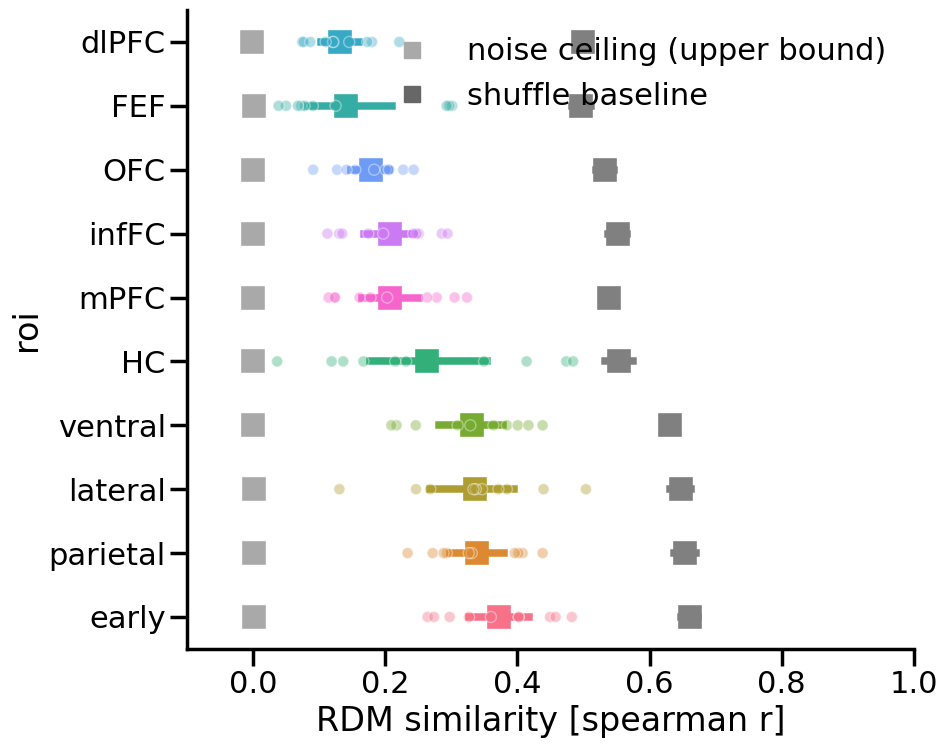

In [61]:
# ── ROI RSA pointplot: observed vs shuffle baseline + noise ceiling ───────────
# sort by mean RSA across subjects
roi_order = roi_df.groupby('roi')['rsa'].mean().sort_values(ascending=True).index.tolist()

shuffle_color_code = "#676767ff"

plt.figure(figsize=(10, 8))
sns.pointplot(
    data=roi_df, y='roi', x='rsa', order=roi_order,
    hue='roi', palette='husl', legend=False,
    errorbar=('ci', 95), capsize=0, orient='h', markers='s',
)
# subjects as faint points
sns.stripplot(
    data=roi_df, x='rsa', y='roi', order=roi_order,
    hue='roi', palette='husl', legend=False,
    alpha=0.4, jitter=False, dodge=False,
    size=8, edgecolor='white', linewidth=1, orient='h',
)

# noise ceiling (upper bound) — pointplot with 95% CI over hemispheres
if nc_df is not None and not nc_df.empty:
    sns.pointplot(
        data=nc_df, x='nc', y='roi', order=roi_order,
        color='gray', markers='s', errorbar=('ci', 95),
        orient='h', zorder=0, join=False, legend=False,
    )

# shuffle baseline — same treatment as the noise ceiling: pointplot with 95% CI
# over the per-hemisphere baselines (baseline_df hemi in {lh, rh}).
base_df = baseline_df.query("hemi in ['lh', 'rh']")
# use empty squares as markers
sns.pointplot(
    data=base_df, x='null_mean', y='roi', order=roi_order,
    color='darkgray', markers='s', errorbar=('ci', 95),
    orient='h', zorder=6, join=False, legend=False,  alpha=1
)

from matplotlib.lines import Line2D
plt.legend(handles=[
    Line2D([0], [0], marker='s', color='darkgray', linestyle='',
           label='noise ceiling (upper bound)'),
    Line2D([0], [0], marker='s', color=shuffle_color_code, linestyle='',
           label='shuffle baseline'),
], frameon=False)

plt.xlim(-0.1, 1)
plt.ylabel('roi')
plt.xlabel('RDM similarity [spearman r]')
sns.despine()
plt.tight_layout()
for fname in ('roi_rsa_pointplot.pdf', 'roi_rsa_pointplot_with_nc.pdf'):
    plt.savefig(os.path.join(output_dir, fname), dpi=300, bbox_inches='tight')
print('Saved roi_rsa_pointplot.pdf / roi_rsa_pointplot_with_nc.pdf')


# ── Quintessential significance report (one-sample t-test vs shuffle baseline) ─
def _stars(p):
    return '***' if p < 1e-3 else '**' if p < 1e-2 else '*' if p < 5e-2 else 'n.s.'

print('\nPer-ROI RSA vs shuffle baseline — one-sample t-test over subjects '
      '(one-sided), BH-FDR across ROIs:')
rep = roi_stats.sort_values('mean_rsa', ascending=False)
print(f"  {'roi':<8}{'mean r':>8}{'baseline':>10}{'t':>8}{'p':>9}{'p_fdr':>9}  sig")
for _, r in rep.iterrows():
    print(f"  {r['roi']:<8}{r['mean_rsa']:>8.3f}{r['baseline']:>10.3f}{r['t']:>8.2f}"
          f"{r['p']:>9.4f}{r['p_fdr']:>9.4f}  {_stars(r['p_fdr'])}")
sig = rep.query('p_fdr < 0.05')['roi'].tolist()
print(f"\nSignificant above shuffle baseline (FDR<.05): "
      f"{', '.join(sig) if sig else 'none'}")

Saved roi_nc_barplot.pdf


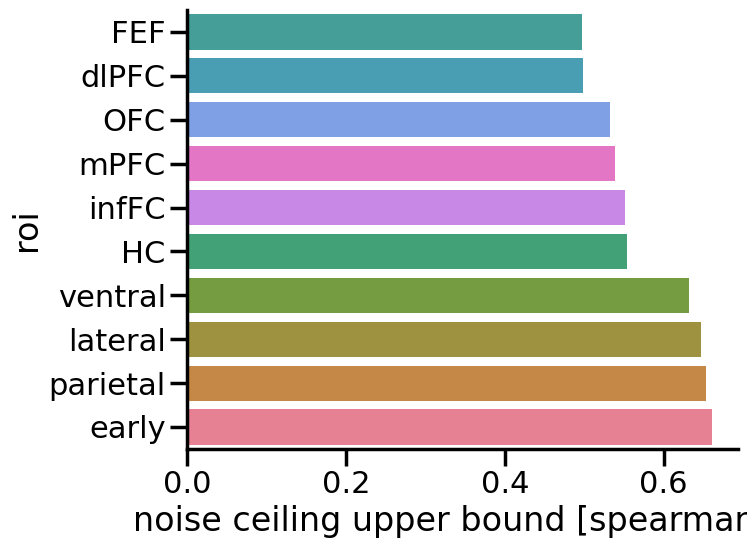

In [23]:
if not nc_df.empty:
    nc_order = nc_df.groupby('roi')['nc'].mean().sort_values(ascending=True).index.tolist()

    plt.figure(figsize=(8, 6))
    sns.barplot(
        data=nc_df,
        y='roi',
        x='nc',
        order=nc_order,
        hue='roi',
        palette='husl',
        errorbar=None,
        capsize=0,
        orient='h',
    )
    plt.ylabel('roi')
    plt.xlabel('noise ceiling upper bound [spearman r]')
    sns.despine()
    plt.tight_layout()
    plt.savefig(
        os.path.join(output_dir, 'roi_nc_barplot.pdf'),
        dpi=300, bbox_inches='tight'
    )
    #plt.close()
    print('Saved roi_nc_barplot.pdf')
else:
    print('nc_stc not available — skipping NC barplot.')